# Taller 3 SI7016: Fine-tuning vs RAG + Prompt Engineering, evaluación consolidada

**Universidad EAFIT, NLP Aplicado 2026-2.** Equipo: Alejandro Silva Zuluaga, Isabel Jurado, David Botero.

Este notebook reúne, en un solo lugar ejecutable, la evaluación cuantitativa del taller. **No vuelve a llamar a ningún modelo ni a GCP**: lee las respuestas que ya generaron los sistemas desplegados (guardadas en `results/`) y recalcula las métricas con el mismo código del repositorio (`src/eval/`). Así cualquiera puede verificar las cifras del README sin credenciales ni GPU.

| Sistema | Recuperador | Generador | Dónde corrió |
| --- | --- | --- | --- |
| `base` | ninguno | `google/gemma-7b-it` sin afinar | Endpoint de Vertex AI Model Garden |
| `finetuning` | ninguno | `gemma-7b-it` + QLoRA fusionado | Custom Job de Vertex (lotes) y VM con vLLM |
| `rag` | FAISS local, `multilingual-e5-base` | `gemma-7b-it` sin afinar | FAISS en CPU + endpoint de Vertex |
| `rag-vertex` | Vertex AI RAG Engine, `text-embedding-005` | `gemini-2.5-flash` | Servicio administrado de Agent Platform |

**Mapa del resto de la entrega** (la ejecución en GCP está en scripts, no en notebooks, porque cada paso es un job o un despliegue):

| Paso | Código | Documentación |
| --- | --- | --- |
| Corpus y dataset QA (100 pares, split 80/20, seed 42) | `src/data/` | `data/qa/README.md` |
| Línea base en Model Garden | `src/deploy/00` a `05` | `src/deploy/README.md` |
| Fine-tuning QLoRA, fusión de adaptadores, inferencia | `src/finetuning/` | `src/finetuning/README.md` |
| Modelo afinado servido con vLLM en VM L4 | `src/deploy/07-vm-vllm.sh`, `08-predict-vllm.py` | `docs/fase3-runbook.md` |
| RAG local (FAISS, BM25, híbrido, reranker) | `src/rag/` | `README.md` |
| RAG en Vertex AI RAG Engine | `src/rag/vertex_rag_engine.py` | `docs/fase3-runbook.md` |
| Interfaz de consulta | `app/streamlit_app.py` | `evidencia/` |
| Prompts exactos | `prompts/*.md` | |
| Evidencia del despliegue | `evidencia/Evidencias-Taller3.docx`, `evidencia/capturas/` | `evidencia/README.md` |
| Costos y ética | | `docs/costos-gcp.md`, `docs/declaracion-etica.md` |

## 1. Entorno

Solo hace falta `pandas`, `matplotlib` y `rouge-score==0.1.2` (la misma versión de `requirements.txt`). Se ejecuta desde la carpeta `notebooks/` o desde la raíz del repositorio.

In [1]:
import json, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src" / "eval"))
from metrics import ROUGE_TIPOS, es_valida, limpiar_prediccion, rouge, recall_at_k

RES = RAIZ / "results"
QA = RAIZ / "data" / "qa"
leer = lambda p: [json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
pd.set_option("display.max_colwidth", 120)
print("Respuestas disponibles:", sorted(p.name for p in RES.glob("respuestas-*.jsonl")))

Respuestas disponibles: ['respuestas-base.jsonl', 'respuestas-finetuning-vllm.jsonl', 'respuestas-finetuning.jsonl', 'respuestas-rag-vertex.jsonl', 'respuestas-rag.jsonl']


## 2. Dataset de evaluación

Enfoque **instructivo**: 100 pares pregunta-respuesta redactados a partir del texto de las 33 normas fuente, con cada cifra verificada contra su norma (`src/data/verify_qa_grounding.py`). 80 se usan para entrenar y 20 para evaluar; las 20 de evaluación nunca se vieron en el entrenamiento.

In [2]:
todo = pd.DataFrame(leer(QA / "normas_ruido_all.jsonl"))
ev = pd.DataFrame(leer(QA / "normas_ruido_eval.jsonl"))
print(f"Pares totales: {len(todo)}  |  evaluación: {len(ev)}  |  normas fuente distintas: {todo.source_file.nunique()}")
print(f"Largo medio de la referencia (eval): {ev.answer.str.len().mean():.0f} caracteres")
ev[["question", "source_file", "section_label"]].head(8)

Pares totales: 100  |  evaluación: 20  |  normas fuente distintas: 33
Largo medio de la referencia (eval): 568 caracteres


,question,source_file,section_label
0,What does ISO 3382-1 specify?,UNE-EN ISO 3382-1.pdf,1
1,"What background noise criterion does ISO 3744 impose, and how is the correction K1 applied?","ISO_3744_2010_,_Acoustics_,_Determination.pdf",4.2.1 / 8.2.3
2,What does ISO 1996-2 require regarding acoustic calibration?,UNE ISO 1996 - 2 .pdf,5.2
3,"Which physical effects are included in the ISO 9613-2 algorithms, and in which frequency bands do they work?",ISO 9613-2.pdf,1
4,"What does ISO 3745 specify, and how does its accuracy compare with ISO 3744 and ISO 3746?",ISO 3745.pdf,1.1 / 1.4
5,"According to ISO 9613-1, how should users obtain attenuation coefficients for conditions that are not listed in Tabl...",ISO 9613-1.pdf,6.2
6,"What does ISO 10140-5 cover, and what qualification does it require of a test facility?",UNE-EN ISO 10140-5.pdf,1
7,"What does ISO 16032 measure, and which quantity is reported?",UNE-EN ISO 16032.pdf,1


## 3. Prompt engineering

Tres técnicas aplicadas igual a los cuatro sistemas (zero-shot con *role prompting*, few-shot y chain-of-thought), más `rag-anclado` en los dos RAG. El texto exacto de cada una está en `prompts/`. Aquí se muestran el zero-shot, que es además el formato con que se entrenó el modelo afinado, y el prompt anclado del RAG.

In [3]:
for nombre in ["zero-shot.md", "rag-anclado.md"]:
    texto = (RAIZ / "prompts" / nombre).read_text(encoding="utf-8")
    ini = texto.find("```text", texto.find("## Prompt exacto"))
    print(f"===== prompts/{nombre} =====")
    print(texto[ini:texto.find("```", ini + 7) + 3] if ini >= 0 else texto)
    print()

===== prompts/zero-shot.md =====
```text
<start_of_turn>user
You are an expert on ISO, UNE and BS acoustics standards for noise measurement. Answer the question precisely and cite the clause when you know it.

Question: {q}<end_of_turn>
<start_of_turn>model

```

===== prompts/rag-anclado.md =====
```text
<start_of_turn>user
You are an expert on ISO, UNE and BS acoustics standards for noise measurement. Answer the question using ONLY the excerpts below. Quote the exact passage you used and cite it by its number, e.g. [2]. If the answer is not in the excerpts, reply exactly "I do not have enough information."

Context:
{context}

Question: {q}<end_of_turn>
<start_of_turn>model

```



## 4. Curva de entrenamiento del fine-tuning

QLoRA 4-bit NF4 sobre `gemma-7b-it`, LoRA r=16 / alpha=32, 10 épocas, 100 pasos, 1 x NVIDIA L4 en un Custom Training Job de Vertex (847 s). Valores transcritos de Cloud Logging en `evidencia/curva-loss-entrenamiento.md` (captura: `evidencia/capturas/08-logs-curva-loss.png`).

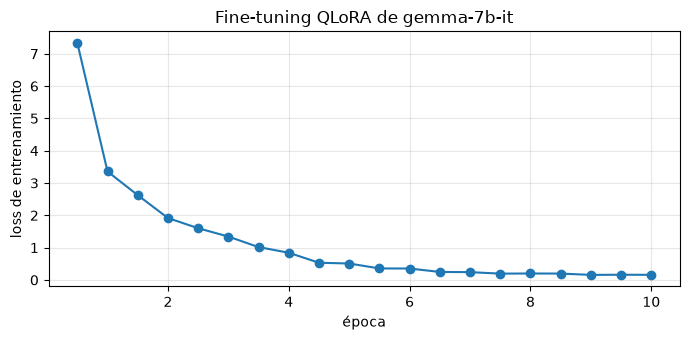

loss inicial 7.335 -> final 0.159


In [4]:
filas = []
for linea in (RAIZ / "evidencia" / "curva-loss-entrenamiento.md").read_text(encoding="utf-8").splitlines():
    partes = [p.strip() for p in linea.strip().strip("|").split("|")]
    if len(partes) == 3:
        try:
            filas.append(tuple(float(p) for p in partes))
        except ValueError:
            pass
curva = pd.DataFrame(filas, columns=["epoca", "loss", "grad_norm"])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(curva.epoca, curva.loss, marker="o")
ax.set_xlabel("época"); ax.set_ylabel("loss de entrenamiento"); ax.set_title("Fine-tuning QLoRA de gemma-7b-it")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"loss inicial {curva.loss.iloc[0]:.3f} -> final {curva.loss.iloc[-1]:.3f}")

## 5. Métricas: ROUGE para la generación y Recall@K para la recuperación

Se recalculan desde las respuestas guardadas, fila por fila, con las mismas funciones de `src/eval/metrics.py`. ROUGE-1/2/L como F-measure; en chain-of-thought se puntúa solo lo que sigue a la última línea `Answer:` y en rag-anclado se quitan las citas `[n]`. Recall@K se mide a nivel de documento: acierto si la norma fuente de la pregunta está entre los K primeros documentos recuperados.

In [5]:
SISTEMAS = ["base", "finetuning", "rag", "rag-vertex"]
filas = []
for s in SISTEMAS:
    for f in leer(RES / f"respuestas-{s}.jsonl"):
        r = {"system": s, "technique": f["technique"], "question": f["question"], "valida": es_valida(f["prediction"])}
        if r["valida"]:
            r.update(rouge(limpiar_prediccion(f["prediction"], f["technique"]), f["reference"]))
        if f.get("retrieved_sources"):
            for k in (1, 3, 5):
                r[f"recall@{k}"] = recall_at_k(f["source_file"], f["retrieved_sources"], k)
        filas.append(r)
det = pd.DataFrame(filas)
tabla = (det.groupby(["system", "technique"])
            .agg(n=("question", "size"), n_validas=("valida", "sum"),
                 rouge1=("rouge1", "mean"), rouge2=("rouge2", "mean"), rougeL=("rougeL", "mean"),
                 **{f"recall@{k}": (f"recall@{k}", "mean") for k in (1, 3, 5)})
            .round(4).reset_index())
tabla

,system,technique,n,n_validas,rouge1,rouge2,rougeL,recall@1,recall@3,recall@5
0,base,chain-of-thought,20,20,0.2578,0.0733,0.1820,NaN,NaN,NaN
1,base,few-shot,20,20,0.2818,0.0768,0.1872,NaN,NaN,NaN
2,base,zero-shot,20,20,0.3251,0.0792,0.2088,NaN,NaN,NaN
3,finetuning,chain-of-thought,20,20,0.3622,0.1137,0.2341,NaN,NaN,NaN
4,finetuning,few-shot,20,20,0.3910,0.1379,0.2535,NaN,NaN,NaN
5,finetuning,zero-shot,20,20,0.4075,0.1486,0.2709,NaN,NaN,NaN
6,rag,chain-of-thought,20,20,0.3243,0.1636,0.2527,0.90,0.95,0.95
7,rag,few-shot,20,20,0.2550,0.1169,0.1846,0.90,0.95,0.95
8,rag,rag-anclado,20,20,0.4248,0.1997,0.2913,0.90,0.95,0.95
9,rag,zero-shot,20,20,0.4423,0.2170,0.3065,0.90,0.95,0.95


**Verificación contra la tabla del README.** La tabla recién calculada debe coincidir con `results/metricas-comparativas.csv`, que es la que se reporta.

In [6]:
guardada = pd.read_csv(RES / "metricas-comparativas.csv")
cmp = tabla.merge(guardada, on=["system", "technique"], suffixes=("", "_csv"))
dif = max((cmp[c] - cmp[f"{c}_csv"]).abs().max() for c in ["rouge1", "rouge2", "rougeL"])
print(f"Filas comparadas: {len(cmp)} de {len(guardada)}  |  diferencia máxima en ROUGE: {dif:.5f}")
assert len(cmp) == len(guardada) and dif < 1e-3, "La tabla recalculada no coincide con la reportada"
print("OK: las métricas del README se reproducen desde las respuestas guardadas.")

Filas comparadas: 14 de 14  |  diferencia máxima en ROUGE: 0.00000
OK: las métricas del README se reproducen desde las respuestas guardadas.


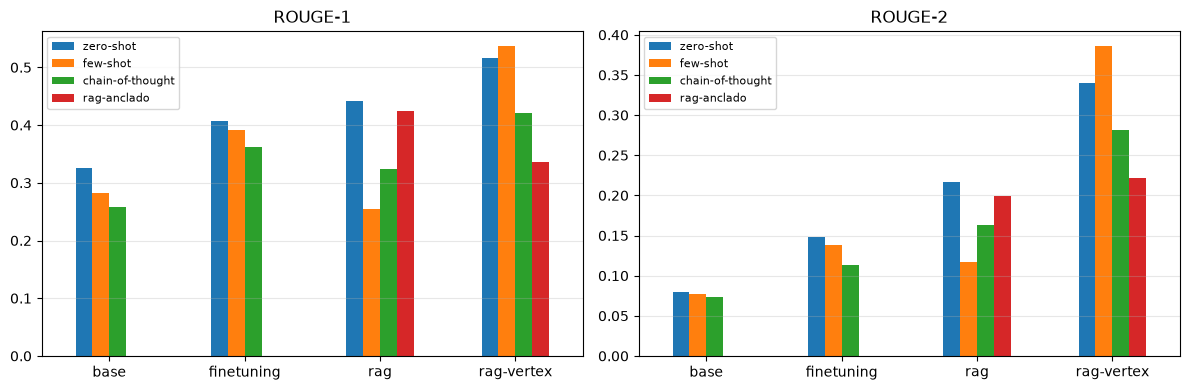

In [7]:
orden_t = ["zero-shot", "few-shot", "chain-of-thought", "rag-anclado"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, met in zip(axes, ["rouge1", "rouge2"]):
    piv = tabla.pivot(index="system", columns="technique", values=met).reindex(SISTEMAS)[orden_t]
    piv.plot.bar(ax=ax, rot=0)
    ax.set_title(met.upper().replace("ROUGE", "ROUGE-")); ax.set_xlabel(""); ax.grid(axis="y", alpha=.3)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Recuperación: FAISS local contra Vertex AI RAG Engine

Esta es la comparación limpia entre recuperadores, porque Recall@K no depende de quién redacta la respuesta.

In [8]:
rec = (det.dropna(subset=["recall@1"]).groupby("system")[["recall@1", "recall@3", "recall@5"]]
          .mean().round(2).rename(index={"rag": "FAISS local", "rag-vertex": "Vertex AI RAG Engine"}))
display(rec)
print("Sobre las 100 preguntas del dataset (FAISS, distintas estrategias de recuperación):")
pd.read_csv(RES / "recall-retrieval-all.csv")

,recall@1,recall@3,recall@5
system,,,
FAISS local,0.90,0.95,0.95
Vertex AI RAG Engine,0.95,1.00,1.00


Sobre las 100 preguntas del dataset (FAISS, distintas estrategias de recuperación):


,modo,recall@1,recall@3,recall@5,recall@10,mrr,n_preguntas,n_normas_indexadas
0,dense,0.74,0.85,0.87,0.94,0.802,100,33
1,bm25,0.37,0.45,0.51,0.62,0.436,100,33
2,hybrid,0.63,0.75,0.83,0.86,0.711,100,33
3,dense+rerank,0.56,0.78,0.83,0.89,0.680,100,33
4,bm25+rerank,0.46,0.59,0.64,0.67,0.537,100,33
5,hybrid+rerank,0.52,0.73,0.83,0.88,0.644,100,33


## 6. El endpoint de vLLM sirve lo mismo que se midió

Las respuestas del modelo afinado de la tabla salieron de un job por lotes. Se repitieron las mismas 60 consultas contra el endpoint de vLLM en la VM (`results/respuestas-finetuning-vllm.jsonl`) para comprobar que las métricas no dependen del camino de inferencia.

In [9]:
def rouge_medio(ruta):
    d = pd.DataFrame([{"technique": f["technique"],
                       **rouge(limpiar_prediccion(f["prediction"], f["technique"]), f["reference"])}
                      for f in leer(ruta) if es_valida(f["prediction"])])
    return d.groupby("technique")["rouge1"].mean()
pd.DataFrame({"ROUGE-1 lotes (Vertex Custom Job)": rouge_medio(RES / "respuestas-finetuning.jsonl"),
              "ROUGE-1 endpoint (vLLM en VM)": rouge_medio(RES / "respuestas-finetuning-vllm.jsonl")}).round(4)

,ROUGE-1 lotes (Vertex Custom Job),ROUGE-1 endpoint (vLLM en VM)
technique,,
chain-of-thought,0.3622,0.3773
few-shot,0.3910,0.4020
zero-shot,0.4075,0.4059


## 7. Cómo responde cada sistema: idioma, longitud y citas

ROUGE no explica por sí solo las diferencias entre técnicas. Estos rasgos de forma (misma lógica que `src/eval/analizar_respuestas.py`) muestran, por ejemplo, que `rag-vertex` con `rag-anclado` responde en español la mitad de las veces porque cita fragmentos de las ediciones UNE, mientras las referencias están en inglés.

In [10]:
from analizar_respuestas import en_espanol, tiene_cita
forma = []
for s in SISTEMAS:
    for f in leer(RES / f"respuestas-{s}.jsonl"):
        p = f["prediction"] or ""
        forma.append({"system": s, "technique": f["technique"], "espanol": en_espanol(p),
                      "largo": len(p), "con_citas": tiene_cita(p)})
forma = pd.DataFrame(forma).groupby(["system", "technique"]).agg(
    en_espanol=("espanol", "sum"), largo_medio=("largo", "mean"), con_citas=("con_citas", "sum")).round(0)
print(f"Referencias: largo medio {ev.answer.str.len().mean():.0f} caracteres, todas en inglés")
forma

Referencias: largo medio 568 caracteres, todas en inglés


en_espanol  largo_medio  con_citas
system     technique                                           
base       chain-of-thought           0        648.0          1
           few-shot                   0        409.0          0
           zero-shot                  0        742.0          5
finetuning chain-of-thought           0        501.0          0
           few-shot                   0        675.0          0
           zero-shot                  0        490.0          0
rag        chain-of-thought           2        558.0          9
           few-shot                   0        204.0          0
           rag-anclado                0        500.0          6
           zero-shot                  0        426.0          4
rag-vertex chain-of-thought           1       1080.0         20
           few-shot                   0        367.0          1
           rag-anclado               10        630.0         20
           zero-shot                  0        674.0         10

## 8. Evidencia cualitativa

La misma pregunta, zero-shot, en los cuatro sistemas.

In [11]:
PREGUNTA = "What does ISO 3382-1 specify?"
print("REFERENCIA:\n", ev.set_index("question").loc[PREGUNTA, "answer"], "\n")
for s in SISTEMAS:
    f = next(x for x in leer(RES / f"respuestas-{s}.jsonl") if x["question"] == PREGUNTA and x["technique"] == "zero-shot")
    print(f"--- {s} ---\n{f['prediction'][:600]}\n")

REFERENCIA:
 ISO 3382-1 specifies methods for measuring reverberation time and other room acoustic parameters in performance spaces. It describes the measurement procedure, the instrumentation required and the method for evaluating the data and presenting the test report. It is intended for the application of modern digital measurement techniques and for evaluating room acoustic parameters from impulse responses. 

--- base ---
Sure, here is the answer to the question:

ISO 3382-1 specifies the requirements for the measurement of sound power levels of noise sources using sound intensity methods. It covers the general principles of measurement, measurement equipment, and measurement procedures.

**Clause 4.1 of ISO 3382-1** specifically states the requirements for the measurement of sound power levels using sound intensity methods.

--- finetuning ---
ISO 3382-1 specifies methods for measuring the reverberation time in ordinary rooms. It describes the measurement procedure, the equipmen

## 9. Conclusiones

1. **El fine-tuning mejora al modelo base en las tres técnicas.** Su peor configuración (chain-of-thought, ROUGE-1 0.362) supera a la mejor del base (zero-shot, 0.325). En zero-shot, ROUGE-2 casi se duplica (0.079 a 0.149): el modelo aprende el dominio y la forma de redactar de las normas.
2. **El fine-tuning no fija las cifras.** Con 80 ejemplos el modelo aprende de qué trata cada norma, pero inventa valores concretos (ver el caso del criterio de ruido de fondo de ISO 3744 en el README).
3. **El RAG gana en fidelidad literal.** Con el mismo generador (`gemma-7b-it`), el RAG local supera al afinado en ROUGE-2 (0.217 contra 0.149 en zero-shot), porque copia del texto recuperado.
4. **La recuperación no es el cuello de botella.** Recall@5 de 0.95 con FAISS y 1.00 con Vertex AI RAG Engine sobre las 20 preguntas.
5. **`rag-vertex` tiene los mejores ROUGE, pero cambia recuperador y generador a la vez** (Gemini 2.5 Flash), así que su ventaja no se atribuye solo al servicio administrado.
6. **Limitación de la evaluación:** las referencias están solo en inglés y parte del corpus en español (ediciones UNE); ROUGE castiga respuestas correctas y bien ancladas que citan la edición en español.
7. **La conclusión no depende del camino de inferencia:** el endpoint de vLLM y el job por lotes dan ROUGE-1 prácticamente iguales.

Trabajo futuro: medir `rag-vertex` con el modelo afinado como generador (`vertex_rag_engine.py run --generator vllm`, ya implementado), añadir métricas tipo RAGAS y referencias bilingües.